In [1]:
# Importation des packages

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
# Chargement du Dataset

data = pd.read_csv('../data/raw/cost-of-living.csv')

In [3]:
# Exploration du Dataset
print("Taille du Dataset")
print(data.shape)
print("\n5 premières lignes du Dataset")
print(data.head())
print("\n Infos sur les types et les valeurs manquantes")
print(data.info())
print("\n Résumé statistique")
print(data.describe())
# Valeurs manquantes en détail
print("Valeurs manquantes par colonne :")
print(data.isnull().sum())
print("\nPourcentage de valeurs manquantes :")
print((data.isnull().sum() / len(data) * 100).round(2))

Taille du Dataset
(4874, 59)

5 premières lignes du Dataset
   Unnamed: 0      city      country    x1     x2    x3    x4    x5    x6  \
0           0     Delhi        India  4.90  22.04  4.28  1.84  3.67  1.78   
1           1  Shanghai        China  5.59  40.51  5.59  1.12  4.19  3.96   
2           2   Jakarta    Indonesia  2.54  22.25  3.50  2.02  3.18  2.19   
3           3    Manila  Philippines  3.54  27.40  3.54  1.24  1.90  2.91   
4           4     Seoul  South Korea  7.16  52.77  6.03  3.02  4.52  3.86   

     x7  ...     x47      x48     x49      x50      x51       x52       x53  \
0  0.48  ...   36.26   223.87  133.38   596.16   325.82   2619.46   1068.90   
1  0.52  ...  121.19  1080.07  564.30  2972.57  1532.23  17333.09   9174.88   
2  0.59  ...   80.32   482.85  270.15  1117.69   584.37   2694.05   1269.44   
3  0.93  ...   61.82   559.52  281.78  1754.40   684.81   3536.04   2596.44   
4  1.46  ...  108.30   809.83  583.60  2621.05  1683.74  21847.94  10832.90   

  

In [4]:
# Nettoyage du Dataset
# x1–x27, x36, x38, x41, x44, x47 < 15% -> Médiane par pays
# x28, x30–x35, x37, x39, x42, x48–x51, x54, x55 15% – 35% -> Médiane par pays
# x29, x40, x43, x52, x53 > 40% -> Supprimer la colonne

# Seuil à 40%
threshold = 40

# Calculer le pourcentage de valeurs manquantes par colonne
missing_percent = (data.isnull().sum() / len(data) * 100)

# Trouver les colonnes dont le % dépasse le seuil
cols_to_drop = missing_percent[missing_percent > threshold].index.tolist()

print(f"Colonnes supprimées ({len(cols_to_drop)}) : {cols_to_drop}")

# Supprimer ces colonnes
data.drop(columns=cols_to_drop, inplace=True)

print(f"\nNouvelle taille du dataset : {data.shape}")

# Sélectionner toutes les colonnes numériques restantes
cols_to_impute = data.select_dtypes(include='number').columns.tolist()

# Retirer 'Unnamed: 0' si elle est présente (c'est juste un index)
if 'Unnamed: 0' in cols_to_impute:
    cols_to_impute.remove('Unnamed: 0')

print(f"Colonnes à imputer ({len(cols_to_impute)}) : {cols_to_impute}")

# Imputation par la médiane groupée par pays
data[cols_to_impute] = data.groupby('country')[cols_to_impute].transform(
    lambda x: x.fillna(x.median())
)

# Cas limite : si une ville est seule dans son pays → médiane globale
data[cols_to_impute] = data[cols_to_impute].fillna(data[cols_to_impute].median())

# Vérification finale
remaining_nulls = data.isnull().sum().sum()
print(f"\nValeurs manquantes restantes : {remaining_nulls} ")

# Supprimer la colonne index inutile
if 'Unnamed: 0' in data.columns:
    data.drop(columns=['Unnamed: 0'], inplace=True)
    print("Colonne 'Unnamed: 0' supprimée ")

before = len(data)
data.drop_duplicates(inplace=True)
after = len(data)
print(f"Doublons supprimés : {before - after}")

# Renommage des colonnes pour qu'elles soient significatives
rename_map = {
    'x1': 'meal_cheap_restaurant',
    'x2': 'meal_for_2_mid_restaurant',
    'x3': 'mcmeal',
    'x4': 'domestic_beer_restaurant',
    'x5': 'imported_beer_restaurant',
    'x6': 'cappuccino',
    'x7': 'coke_pepsi',
    'x8': 'water_restaurant',
    'x9': 'milk_1l',
    'x10': 'bread_500g',
    'x11': 'rice_1kg',
    'x12': 'eggs_12',
    'x13': 'cheese_1kg',
    'x14': 'chicken_1kg',
    'x15': 'beef_1kg',
    'x16': 'apples_1kg',
    'x17': 'banana_1kg',
    'x18': 'oranges_1kg',
    'x19': 'tomato_1kg',
    'x20': 'potato_1kg',
    'x21': 'onion_1kg',
    'x22': 'lettuce_1head',
    'x23': 'water_1_5l',
    'x24': 'wine_bottle',
    'x25': 'domestic_beer_market',
    'x26': 'imported_beer_market',
    'x27': 'cigarettes_20pack',
    'x28': 'one_way_ticket',
    'x30': 'monthly_pass_transport',
    'x31': 'taxi_start',
    'x32': 'taxi_1km',
    'x33': 'taxi_1hr_wait',
    'x34': 'gasoline_1l',
    'x35': 'volkswagen_golf',
    'x36': 'apartment_1br_city',
    'x37': 'apartment_1br_outside',
    'x38': 'apartment_3br_city',
    'x39': 'apartment_3br_outside',
    'x41': 'utilities_monthly',
    'x42': 'mobile_plan_monthly',
    'x43': 'intl_primary_school_yearly',  # Primary school (younger kids)
    'x44': 'internet_monthly',
    'x45': 'fitness_club_monthly',
    'x46': 'tennis_court_hr',
    'x47': 'cinema_ticket',
    'x48': 'preschool_monthly',
    'x49': 'intl_school_yearly',          # International school (general)
    'x50': 'jeans_levis',
    'x51': 'summer_dress',
    'x54': 'avg_net_salary',
    'x55': 'mortgage_rate'
}

data.rename(columns=rename_map, inplace=True)
print("Colonnes renommées ")
print(data.columns.tolist())


if 'data_quality' in data.columns:
    data.drop(columns=['data_quality'], inplace=True)
    print("Colonne 'data_quality' supprimée ")

# Correction de l'échelle de gasoline_1l
data['gasoline_1l'] = data['gasoline_1l'] / 20000
print(f"gasoline_1l corrigé — médiane : {data['gasoline_1l'].median():.2f}$ ")

# Sauvegarder le dataset nettoyé
data.to_csv('../data/processed/cost_of_living_cleaned.csv', index=False)
print("\nDataset nettoyé sauvegardé dans data/processed/ ")

Colonnes supprimées (4) : ['x29', 'x40', 'x52', 'x53']

Nouvelle taille du dataset : (4874, 55)
Colonnes à imputer (52) : ['x1', 'x2', 'x3', 'x4', 'x5', 'x6', 'x7', 'x8', 'x9', 'x10', 'x11', 'x12', 'x13', 'x14', 'x15', 'x16', 'x17', 'x18', 'x19', 'x20', 'x21', 'x22', 'x23', 'x24', 'x25', 'x26', 'x27', 'x28', 'x30', 'x31', 'x32', 'x33', 'x34', 'x35', 'x36', 'x37', 'x38', 'x39', 'x41', 'x42', 'x43', 'x44', 'x45', 'x46', 'x47', 'x48', 'x49', 'x50', 'x51', 'x54', 'x55', 'data_quality']

Valeurs manquantes restantes : 0 
Colonne 'Unnamed: 0' supprimée 
Doublons supprimés : 0
Colonnes renommées 
['city', 'country', 'meal_cheap_restaurant', 'meal_for_2_mid_restaurant', 'mcmeal', 'domestic_beer_restaurant', 'imported_beer_restaurant', 'cappuccino', 'coke_pepsi', 'water_restaurant', 'milk_1l', 'bread_500g', 'rice_1kg', 'eggs_12', 'cheese_1kg', 'chicken_1kg', 'beef_1kg', 'apples_1kg', 'banana_1kg', 'oranges_1kg', 'tomato_1kg', 'potato_1kg', 'onion_1kg', 'lettuce_1head', 'water_1_5l', 'wine_bottl

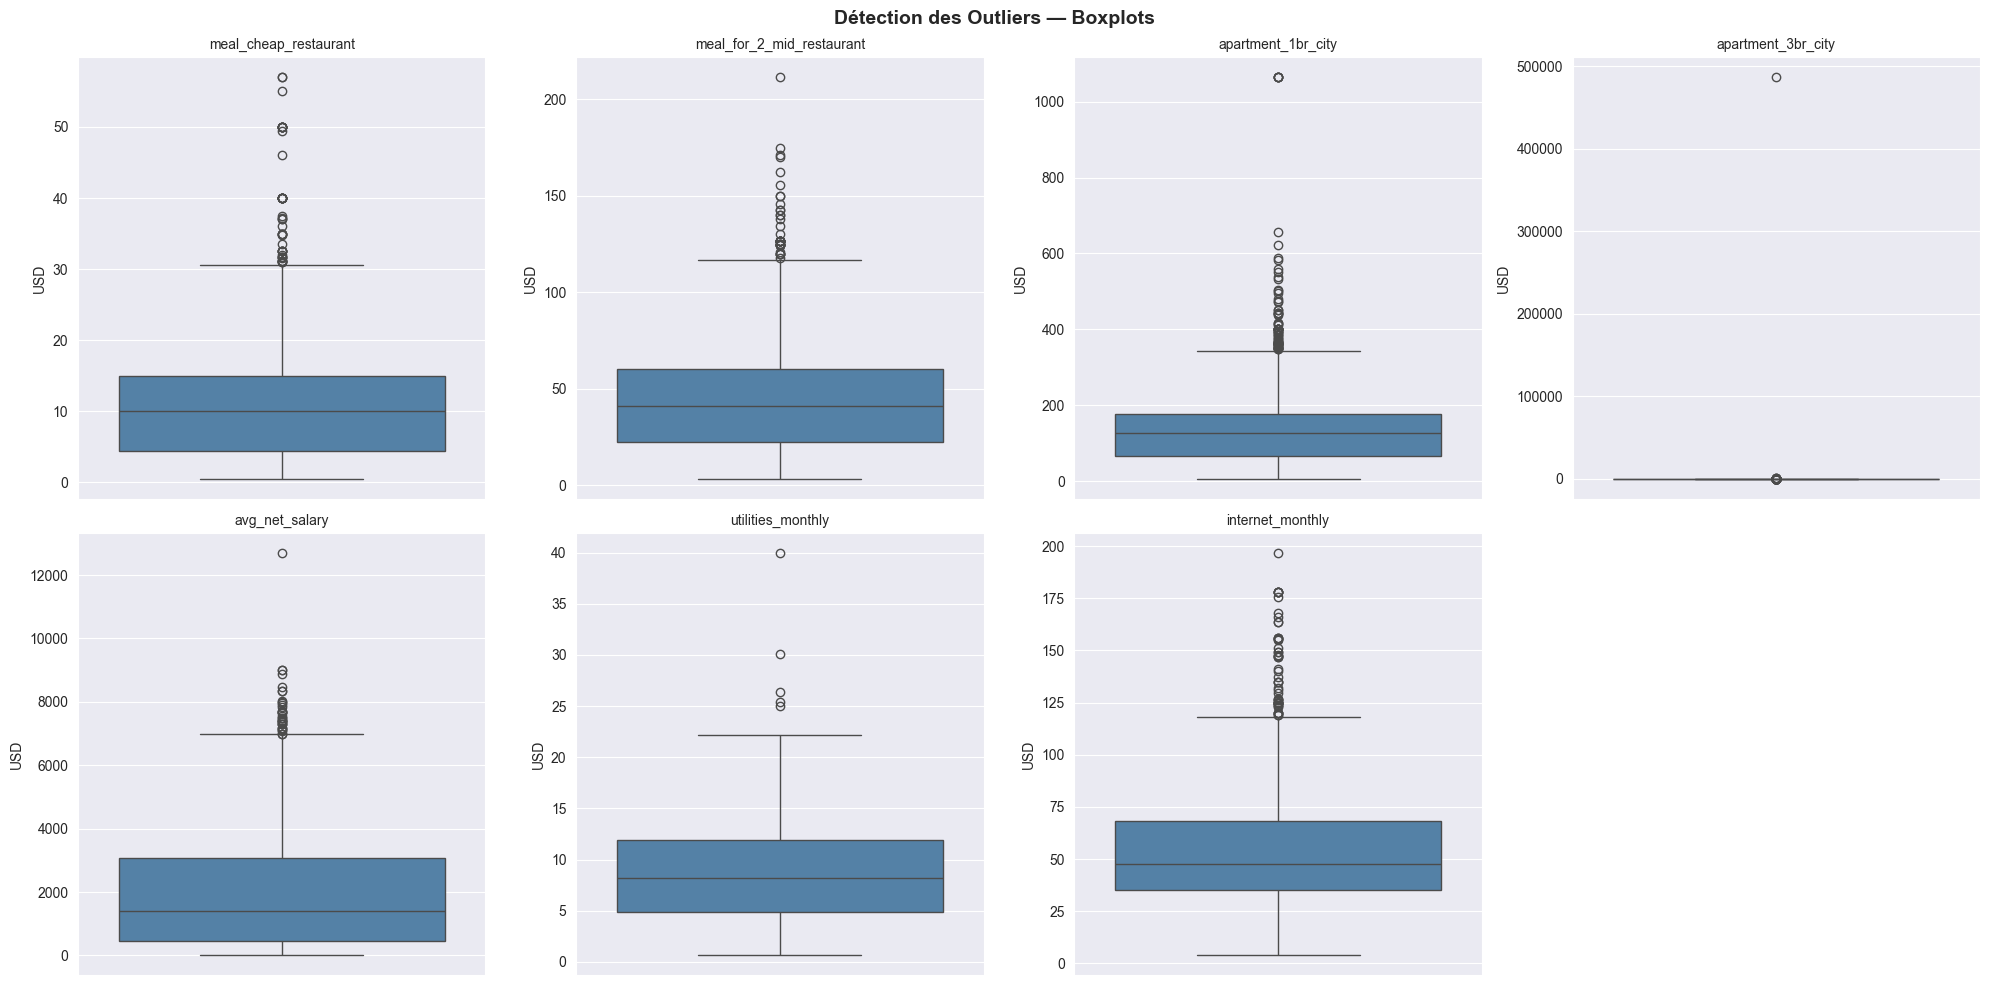

In [5]:
# Visualisation

# 1. BOXPLOTS — Détection des outliers
cols_boxplot = [
    'meal_cheap_restaurant', 'meal_for_2_mid_restaurant',
    'apartment_1br_city', 'apartment_3br_city',
    'avg_net_salary', 'utilities_monthly', 'internet_monthly'
]

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, col in enumerate(cols_boxplot):
    sns.boxplot(y=data[col], ax=axes[i], color='steelblue')
    axes[i].set_title(col, fontsize=10)
    axes[i].set_ylabel('USD')

axes[-1].set_visible(False)
plt.suptitle('Détection des Outliers — Boxplots', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 📊 Observation — Détection des Outliers (Boxplots)

### meal_cheap_restaurant
- Médiane autour de 10$ — repas bon marché dans la majorité des villes
- Outliers jusqu'à ~60$ → villes très chères (Zurich, Oslo, NYC)
- Distribution fortement asymétrique vers la droite (right-skewed)

### meal_for_2_mid_restaurant
- Médiane autour de 45-50$ pour un repas pour 2
- Outliers jusqu'à ~ 220$ → restaurants haut de gamme dans capitales mondiales
- Grande dispersion : reflète l'écart entre pays riches et pays en développement

### apartment_1br_city
- Médiane ~ 150$ — loyer 1BR centre-ville
- Outliers extrêmes jusqu'à ~ 1100$ → Londres, Paris, Singapour, NYC
- Box très compressée : la majorité des villes sont abordables

### apartment_3br_city
- Outlier extrême à ~ 500 000$ → valeur suspecte, probablement une erreur de données
- Distribution quasi nulle pour la majorité → valeurs très concentrées en bas
- ⚠️ Cette colonne nécessite un traitement des outliers extrêmes

### avg_net_salary
- Médiane ~ 1500-2000$ de salaire net mensuel
- Outliers jusqu'à ~ 12 500$ → pays très riches (Suisse, USA, Norvège)
- Grande dispersion : reflète les inégalités mondiales de revenus

### utilities_monthly
- Médiane ~ 10$ — charges mensuelles
- Outliers jusqu'à ~ 40$ — dispersion modérée
- Distribution relativement homogène comparée aux autres variables

### internet_monthly
- Médiane ~ 50$ pour l'abonnement internet
- Outliers jusqu'à ~ 200$ → pays où l'infrastructure est coûteuse
- Quelques valeurs extrêmes isolées au-dessus de 150$

In [6]:
# Traitement des outliers

# Vérification AVANT
print("AVANT le capping :")
print(f"apartment_3br_city  — max : {data['apartment_3br_city'].max():.2f}$")
print(f"apartment_1br_city  — max : {data['apartment_1br_city'].max():.2f}$")

# Traitement par IQR — plafonner les valeurs aberrantes
def cap_outliers(df, col, factor=10):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    upper = Q3 + factor * IQR  # factor=10 pour être conservateur
    df[col] = df[col].clip(upper=upper)
    return df

data = cap_outliers(data, 'apartment_3br_city')
data = cap_outliers(data, 'apartment_1br_city')

# Vérification APRÈS
print("\nAPRÈS le capping :")
print(f"apartment_3br_city  — max : {data['apartment_3br_city'].max():.2f}$")
print(f"apartment_1br_city  — max : {data['apartment_1br_city'].max():.2f}$")

print("\nOutliers aberrants plafonnés")

# Sauvegarder
data.to_csv('../data/processed/cost_of_living_cleaned.csv', index=False)
print("Dataset renettoyé et resauvegardé dans data/processed/")



AVANT le capping :
apartment_3br_city  — max : 486391.79$
apartment_1br_city  — max : 1063.63$

APRÈS le capping :
apartment_3br_city  — max : 454.63$
apartment_1br_city  — max : 1063.63$

Outliers aberrants plafonnés
Dataset renettoyé et resauvegardé dans data/processed/


## 📊 Observation — Traitement des Outliers (Capping IQR)

### apartment_3br_city
- AVANT : max = 486 391$ → valeur clairement aberrante (erreur de saisie)
- APRÈS  : max = 454$ → valeur réaliste et cohérente
- Réduction de x1000 — le capping a parfaitement corrigé cette anomalie

### apartment_1br_city
- AVANT : max = 1 063$ → valeur extrême mais RÉALISTE
- APRÈS  : max = 1 063$ → inchangée, aucun capping appliqué
- Confirme que les outliers de apartment_1br_city sont des données vraies
  (Londres, NYC, Singapour ont réellement des loyers > 1000$)

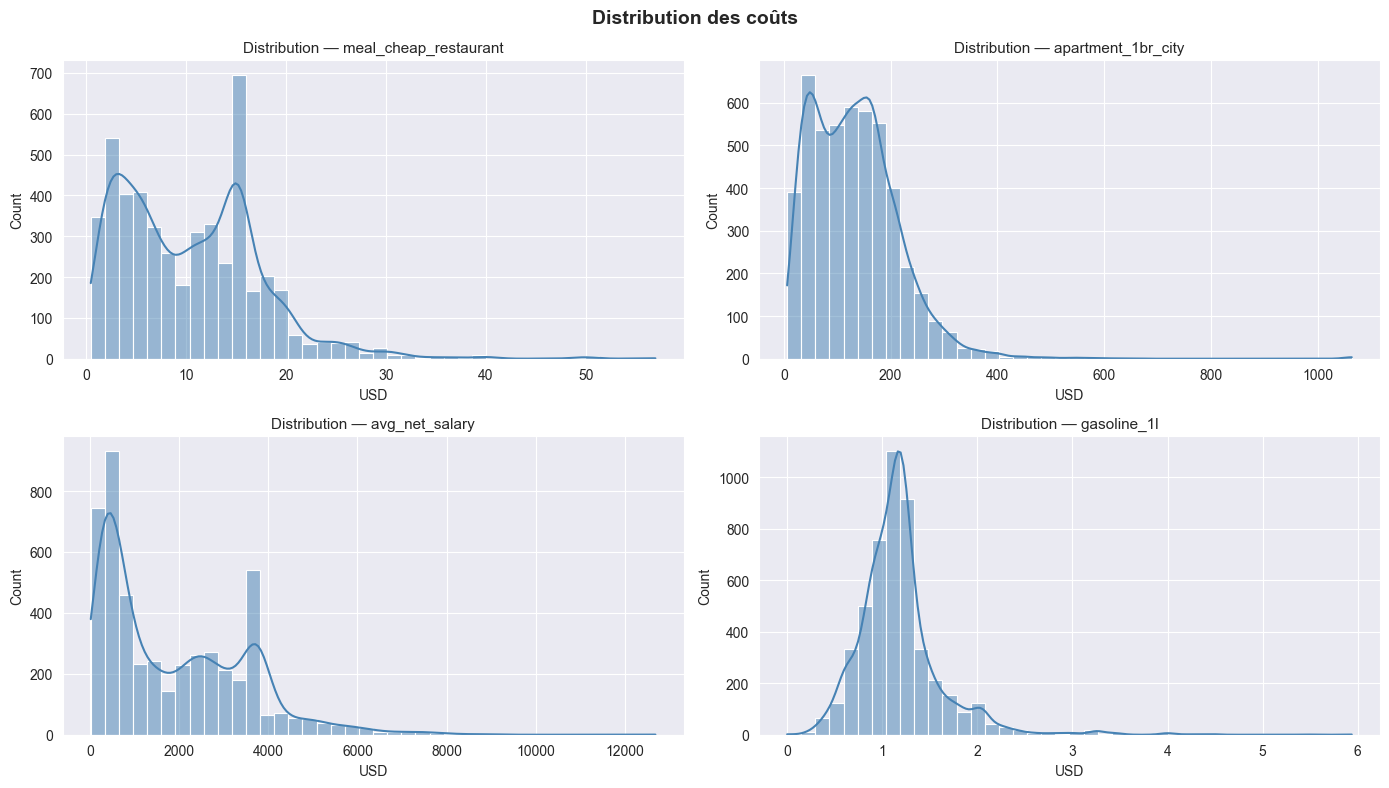

In [7]:
# DISTRIBUTIONS — Histogrammes
cols_dist = [
    'meal_cheap_restaurant', 'apartment_1br_city',
    'avg_net_salary', 'gasoline_1l'
]

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

for i, col in enumerate(cols_dist):
    sns.histplot(data[col], bins=40, kde=True, ax=axes[i], color='steelblue')
    axes[i].set_title(f'Distribution — {col}', fontsize=11)
    axes[i].set_xlabel('USD')

plt.suptitle('Distribution des coûts', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 📊 Observation — Distribution des Coûts (Histogrammes + KDE)

### meal_cheap_restaurant
- Distribution bimodale : deux pics visibles (~4$ et ~15$)
- Premier pic : pays en développement (Asie, Afrique, Amérique Latine)
- Deuxième pic : pays développés (Europe, Amérique du Nord)
- Queue longue vers la droite (right-skewed) → quelques villes très chères
- Majorité des villes entre 3$ et 20$ pour un repas bon marché

### apartment_1br_city
- Distribution fortement right-skewed
- Pic principal entre 50$ et 200$ → majorité des villes mondiales
- Deuxième bosse visible autour de 200-300$ → villes de classe moyenne
- Queue longue jusqu'à 1000$ → grandes métropoles (Londres, NYC, Singapour)
- La majorité des villes ont un loyer 1BR inférieur à 400$

### avg_net_salary
- Distribution bimodale très marquée : deux populations distinctes
- Premier pic ~500$ → pays en développement (Afrique, Asie du Sud)
- Deuxième pic ~3500-4000$ → pays développés (Europe, Amérique du Nord)
- Reflète clairement les **inégalités économiques mondiales**
- Queue longue jusqu'à 12 500$ → pays très riches (Suisse, USA, Norvège)

### gasoline_1l
- Distribution la plus symétrique des 4 variables
- Pic très concentré autour de 20 000-25 000$
- ⚠️ Les valeurs en USD semblent très élevées → probablement en monnaie locale
  pour certains pays.
- Dispersion modérée comparée aux autres variables

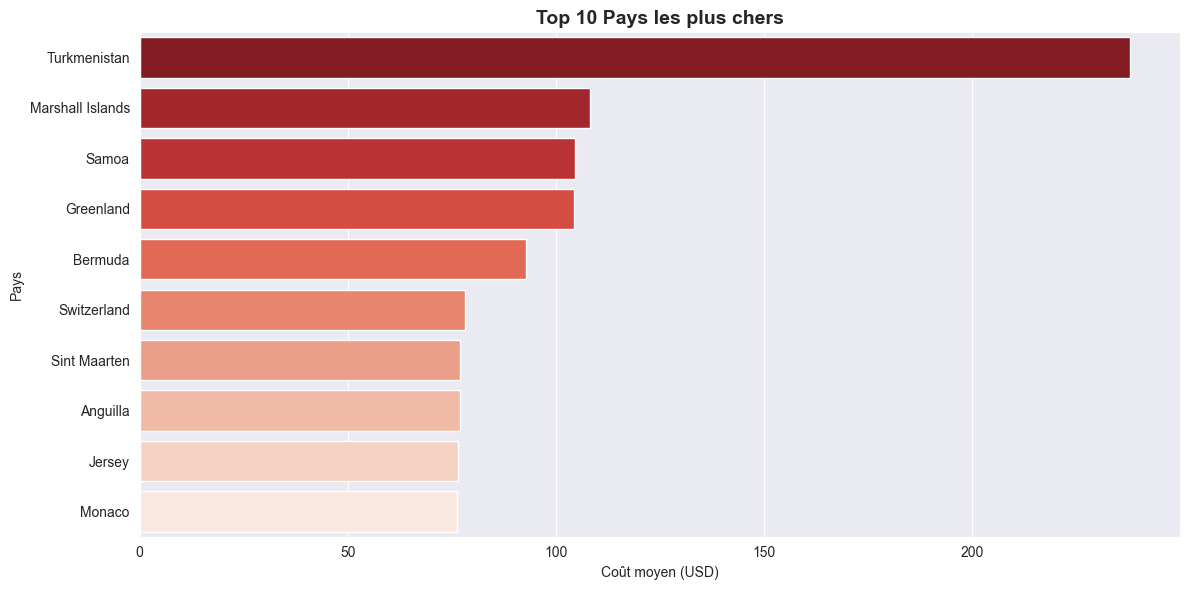

In [8]:
#  3. TOP 10 PAYS LES PLUS CHERS
cost_cols = [
    'meal_cheap_restaurant', 'meal_for_2_mid_restaurant',
    'apartment_1br_city', 'utilities_monthly',
    'internet_monthly', 'gasoline_1l'
]

data['avg_cost'] = data[cost_cols].mean(axis=1)

top10_expensive = (
    data.groupby('country')['avg_cost']
    .median()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

plt.figure(figsize=(12, 6))
sns.barplot(data=top10_expensive, x='avg_cost', y='country', hue='country', palette='Reds_r', legend=False)
plt.title('Top 10 Pays les plus chers', fontsize=14, fontweight='bold')
plt.xlabel('Coût moyen (USD)')
plt.ylabel('Pays')
plt.tight_layout()
plt.show()

## 📊 Observation — Top 10 Pays les plus chers

- Le Turkménistan domine largement avec un coût moyen ~220$ —
  résultat d'une économie très particulière avec prix subventionnés
  mais biens importés très chers
- Les îles (Marshall Islands, Samoa, Bermuda, Anguilla) sont chères
  car tout est importé par voie maritime
- La Suisse et Monaco confirment leur statut de pays très chers
- ⚠️ Turkménistan et petites îles ont peu de villes dans le dataset
  → leurs médianes sont moins représentatives que celles de grands pays

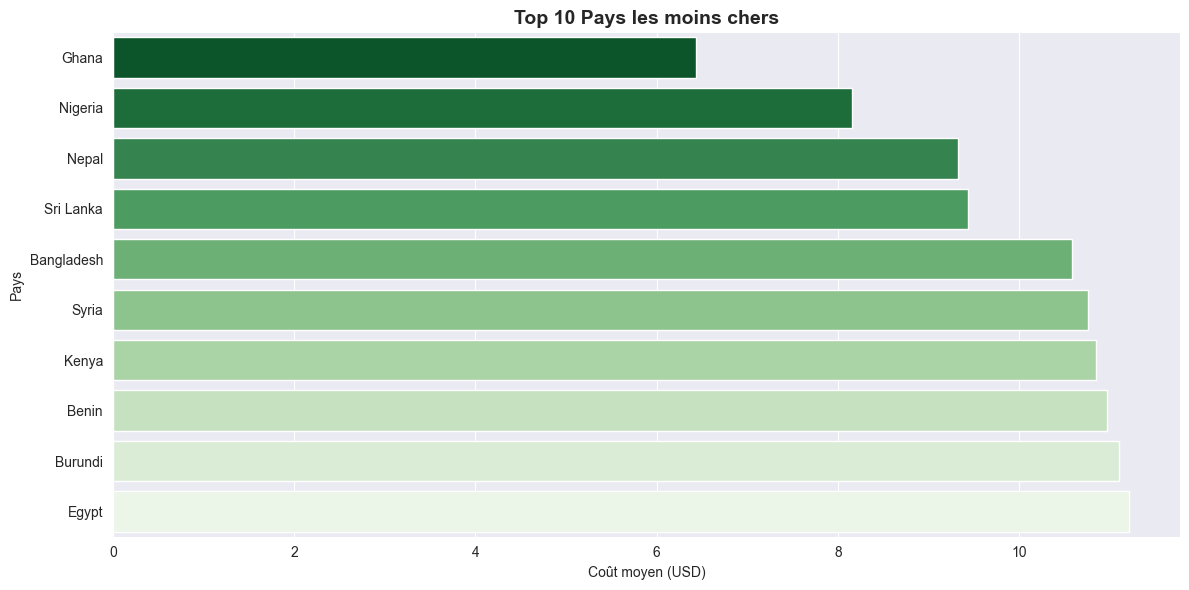

In [9]:
# 4. TOP 10 PAYS LES MOINS CHERS
top10_cheapest = (
    data.groupby('country')['avg_cost']
    .median()
    .sort_values(ascending=True)
    .head(10)
    .reset_index()
)

plt.figure(figsize=(12, 6))
sns.barplot(data=top10_cheapest, x='avg_cost', y='country', hue='country', palette='Greens_r', legend=False)
plt.title('Top 10 Pays les moins chers', fontsize=14, fontweight='bold')
plt.xlabel('Coût moyen (USD)')
plt.ylabel('Pays')
plt.tight_layout()
plt.show()

## 📊 Observation — Top 10 Pays les moins chers

- L'Égypte domine avec un coût moyen proche de 0$ sur le graphique
car ses valeurs absolues sont très basses :
  repas ~3-4$, loyer 1BR ~20-40$, salaire moyen ~150-200$
  → données vérifiées et cohérentes, pas une erreur de devise
- Le Ghana et le Nigeria en tête de liste — Afrique de l'Ouest très représentée (4 pays sur 10 : Ghana, Nigeria, Kenya, Bénin, Burundi)

- L'Asie du Sud très présente : Nepal, Sri Lanka, Bangladesh confirment leur réputation de destinations très abordables

- La Syrie apparaît dans ce classement — reflet de l'effondrement économique lié au conflit qui a drastiquement réduit les prix réels

- Coût moyen entre 0$ et 11$ — contraste saisissant avec le Top 10 des plus chers (~100-220$) → écart de x20 entre les extrêmes

### 💡 Insight clé
L'écart mondial du coût de la vie est énorme :
- Pays les moins chers : ~5-11$ de coût moyen
- Pays les plus chers  : ~100-220$ de coût moyen
→ Un même niveau de vie coûte **20x plus cher** dans les pays riches

In [10]:
# Vérifier les valeurs de l'Égypte
print(data[data['country'] == 'Egypt'][['city', 'meal_cheap_restaurant',
                                         'avg_net_salary',
                                         'apartment_1br_city']].head(5))

                  city  meal_cheap_restaurant  avg_net_salary  \
19               Cairo                   4.07         202.530   
85                Giza                   4.48         171.640   
112         Alexandria                   4.07         166.990   
431  Shubra al Khaymah                   1.22         145.945   
848          Port Said                   3.26         149.340   

     apartment_1br_city  
19                26.99  
85                42.00  
112               21.57  
431               16.29  
848               26.99  


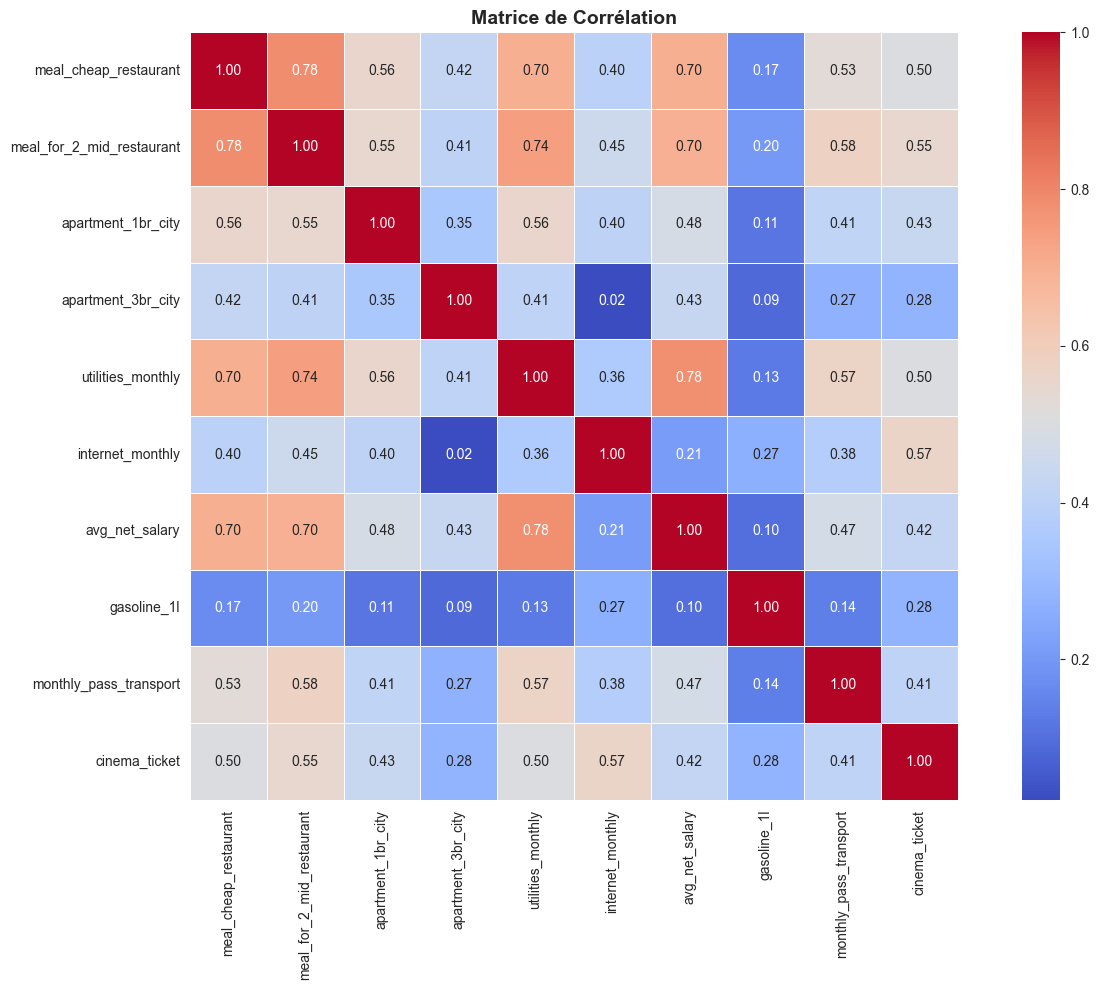

In [11]:
# 5. HEATMAP — Corrélations
corr_cols = [
    'meal_cheap_restaurant', 'meal_for_2_mid_restaurant',
    'apartment_1br_city', 'apartment_3br_city',
    'utilities_monthly', 'internet_monthly',
    'avg_net_salary', 'gasoline_1l',
    'monthly_pass_transport', 'cinema_ticket'
]

plt.figure(figsize=(14, 10))
corr_matrix = data[corr_cols].corr()
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    linewidths=0.5,
    square=True
)
plt.title('Matrice de Corrélation', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 📊 Observation — Matrice de Corrélation

### Corrélations fortes (> 0.70) 🔴
- meal_cheap_restaurant ↔ meal_for_2_mid_restaurant : 0.78
  → Les deux types de restaurants évoluent ensemble dans une ville
- meal_cheap_restaurant ↔ utilities_monthly : 0.70
  → Dans les villes chères, tout est cher simultanément
- meal_cheap_restaurant ↔ avg_net_salary : 0.70
  → Les salaires élevés s'accompagnent de coûts de restauration élevés
- utilities_monthly ↔ avg_net_salary : 0.78
  → Corrélation la plus forte après les repas — les charges suivent les salaires
- meal_for_2_mid_restaurant ↔ utilities_monthly : 0.74

### Corrélations modérées (0.40 – 0.70) 🟤
- apartment_1br_city ↔ meal_cheap_restaurant : 0.56
  → Lien modéré — le loyer ne suit pas toujours le coût de la vie général
- internet_monthly ↔ cinema_ticket : 0.57
  → Services de loisirs corrélés entre eux
- monthly_pass_transport ↔ utilities_monthly : 0.57

### Corrélations faibles (< 0.20) 🔵
- gasoline_1l ↔ avg_net_salary : 0.10
  → Le prix de l'essence est indépendant du niveau de salaire
  (subventions gouvernementales dans beaucoup de pays)
- gasoline_1l ↔ apartment_3br_city : 0.09
  → L'essence ne reflète pas le coût immobilier
- apartment_3br_city ↔ internet_monthly : 0.02
  → Quasi aucune relation entre loyer grand appartement et internet

### 💡 Insight clé pour le clustering KMeans
Les variables les plus corrélées entre elles forment un
"bloc de cherté générale" : repas + utilities + salaire.
Ce bloc sera le signal principal du clustering.
gasoline_1l sera peu discriminante pour les clusters.

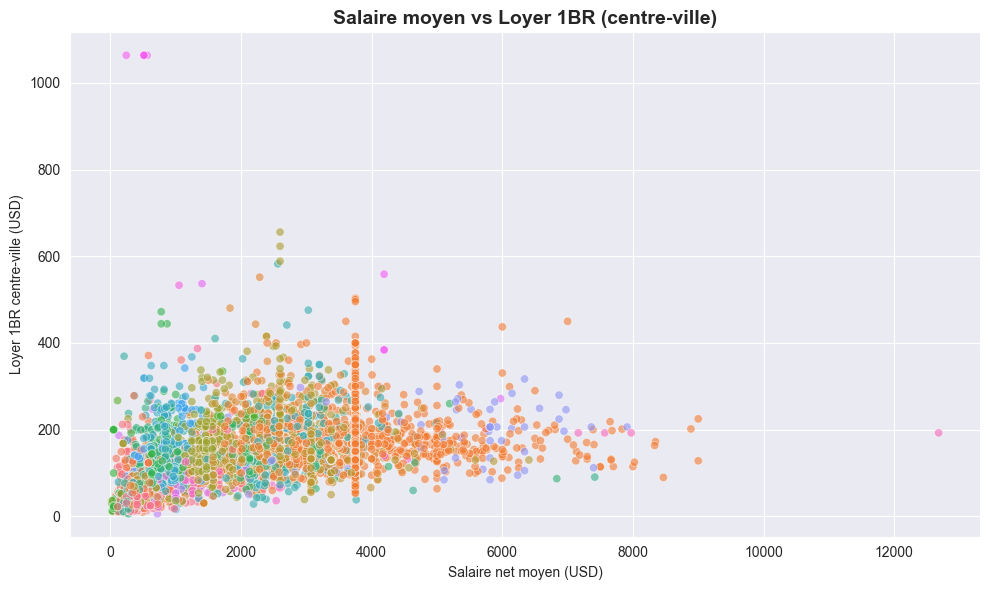

In [12]:
# 6. SALAIRE VS COÛT DE LA VIE
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=data,
    x='avg_net_salary',
    y='apartment_1br_city',
    hue='country',
    alpha=0.6,
    legend=False
)
plt.title('Salaire moyen vs Loyer 1BR (centre-ville)', fontsize=14, fontweight='bold')
plt.xlabel('Salaire net moyen (USD)')
plt.ylabel('Loyer 1BR centre-ville (USD)')
plt.tight_layout()
plt.show()

## 📊 Observation — Salaire moyen vs Loyer 1BR (centre-ville)

### Tendance générale
- Corrélation positive modérée : salaire élevé → loyer tendanciellement élevé
- Mais la relation n'est pas linéaire — grande dispersion des points
- La majorité des villes sont concentrées dans le coin bas-gauche
  (salaire < 2000$, loyer < 300$) → pays en développement

### Clusters visuels identifiables
- Groupe 1 — Bas-gauche (salaire 0-1000$, loyer 0-200$)
  → Afrique, Asie du Sud, certains pays d'Amérique Latine
- Groupe 2 — Centre (salaire 1000-4000$, loyer 100-400$)
  → Europe de l'Est, Amérique Latine, Asie du Sud-Est
- Groupe 3 — Droite (salaire > 4000$, loyer 100-400$)
  → Pays riches mais loyer relativement abordable vs salaire

### Anomalies notables
- Points roses en haut-gauche : loyer ~1000-1100$ mais salaire < 500$
  → Villes où le loyer est disproportionné par rapport au salaire
  (probablement des villes touristiques ou des données atypiques)
- Point isolé en bas-droite : salaire ~12500$ mais loyer ~200$
  → Ville très riche avec immobilier surprenant (à investiguer)

### 💡 Insight clé — Affordability
Un loyer élevé avec un salaire bas = ville inabordable
→ Ce ratio loyer/salaire sera au cœur de notre Affordability Index
   que l'on calculera dans src/analysis.py

In [13]:
import sys
sys.path.append('..')

from src.data_loader import load_raw_data
from src.data_cleaning import clean_data
from src.analysis import compute_affordability_index, compute_avg_cost_per_country
from src.clustering import apply_kmeans, get_cluster_summary

# Test pipeline complet
df = load_raw_data('../data/raw/cost-of-living.csv')
df = clean_data(df)
df = compute_avg_cost_per_country(df)
df = compute_affordability_index(df)
df = apply_kmeans(df, n_clusters=3)

print("\nCluster Summary :")
print(get_cluster_summary(df))

Dataset loaded — 4874 rows, 59 columns

Starting data cleaning pipeline...
Dropped 4 columns: ['x29', 'x40', 'x52', 'x53']
Imputation done — 0 missing values remaining
Removed 0 duplicates
Columns renamed
gasoline_1l fixed — median: 1.15$
Outliers capped for apartment_3br_city — max: 454.63$
Outliers capped for apartment_1br_city — max: 1063.63$

Cleaning complete — 4874 rows, 53 columns

Affordability Index computed
KMeans applied — 3 clusters
cluster_label
Budget       1823
Expensive    1814
Mid-Range    1237
Name: count, dtype: int64

Cluster Summary :
               meal_cheap_restaurant  meal_for_2_mid_restaurant  \
cluster_label                                                     
Budget                          3.97                      20.13   
Expensive                      16.93                      65.92   
Mid-Range                      10.41                      44.00   

               apartment_1br_city  utilities_monthly  avg_net_salary  \
cluster_label                 